# ZDT4 Results

In [ ]:
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_zdt4_front_true
from deap import benchmarks
import matplotlib.pyplot as plt
# 1. Parâmetros (Substituindo as antigas variáveis globais)
IND_SIZE = 10
NPOP = 400
NGEN = 200
NOBJ = 2
NUM_TABLES = int((1 << NOBJ))
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1] * NOBJ

# 2. Configurando o Toolbox para o DTLZ3
def func_zdt4(ind):
    return benchmarks.zdt4(ind)

# 3. Inicialização e Execução
toolbox = build_toolbox(func_zdt4, IND_SIZE, NPOP, NOBJ)
pop_inicial = toolbox.population()
for ind in pop_inicial:
    ind.fitness.values = toolbox.evaluate(ind)

tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)

pareto_real = generate_zdt4_front_true(10000, IND_SIZE)

# 5. Rodando o MEAMT
logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ)

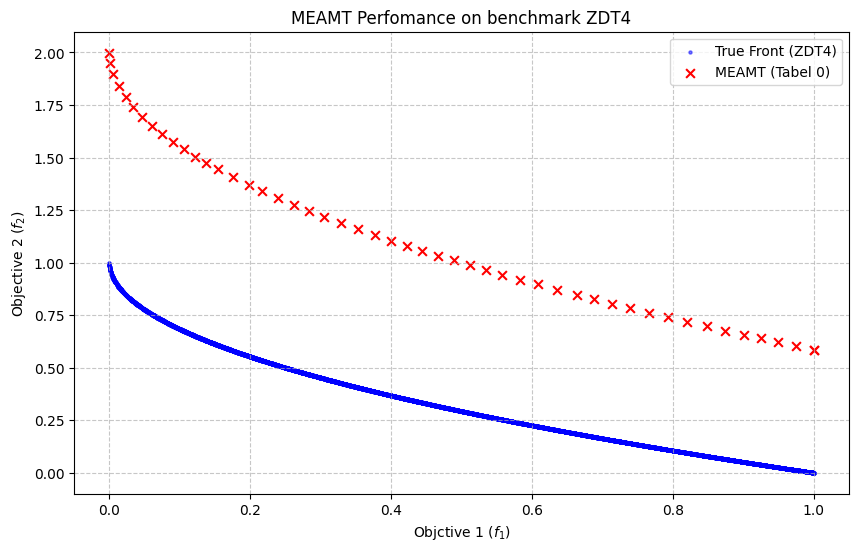

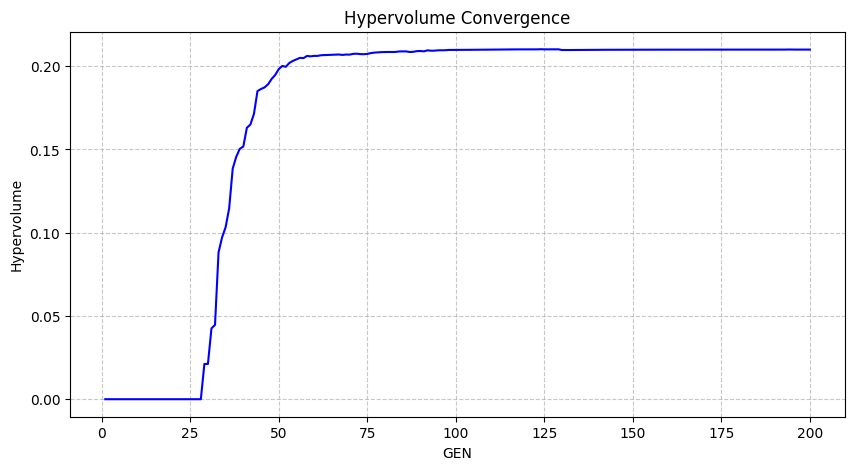

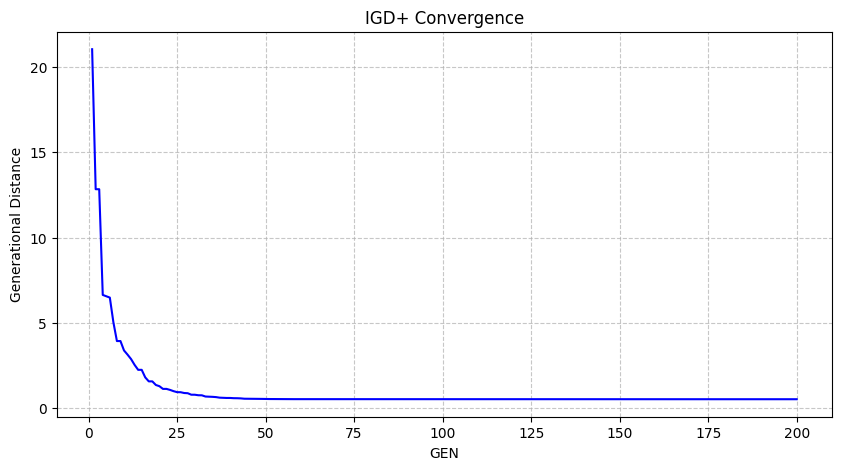

In [12]:
f1_approx = [ind.fitness.values[0] for ind in tabelas[0]]
f2_approx = [ind.fitness.values[1] for ind in tabelas[0]]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT4)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='MEAMT (Tabel 0)')

plt.title("MEAMT Perfomance on benchmark ZDT4")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()